In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/raw/cs-training.csv')
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [3]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [4]:
print(df.describe())

          Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
count  150000.000000     150000.000000                         150000.000000   
mean    75000.500000          0.066840                              6.048438   
std     43301.414527          0.249746                            249.755371   
min         1.000000          0.000000                              0.000000   
25%     37500.750000          0.000000                              0.029867   
50%     75000.500000          0.000000                              0.154181   
75%    112500.250000          0.000000                              0.559046   
max    150000.000000          1.000000                          50708.000000   

                 age  NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  \
count  150000.000000                         150000.000000  150000.000000   
mean       52.295207                              0.421033     353.005076   
std        14.771866                            

In [5]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [6]:
df.drop(columns = ['Unnamed: 0'], inplace = True)
df['age'] = df['age'].replace(0, df['age'].median())

past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in past_due_cols:
    df[col] = df[col].replace(96, 0)
    df[col] = df[col].replace(98, 0)

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print(df.isnull().sum())
print(df.shape)

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64
(150000, 11)


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print(y_train.value_counts(normalize = True))


X_train: (120000, 10)
X_test: (30000, 10)
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


In [8]:
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
lr.fit(X_train, y_train)



scale = (y_train==0).sum() / (y_train==1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train, y_train)



c:\Users\ohrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp

def evaluate_model(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)

    auc = roc_auc_score(y_test, y_prob)
    ks_stat, _ = ks_2samp(y_prob[y_test==1], y_prob[y_test==0])

    print(f"Model: {name}")
    print(f"AUC: {auc:.4f}")
    print(f"KS Statistic: {ks_stat:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

evaluate_model(lr, X_test, y_test, "Logistic Regression")
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Model: Logistic Regression
AUC: 0.8211
KS Statistic: 0.5043
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     27995
           1       0.27      0.62      0.37      2005

    accuracy                           0.86     30000
   macro avg       0.62      0.75      0.65     30000
weighted avg       0.92      0.86      0.88     30000



Model: XGBoost
AUC: 0.8683
KS Statistic: 0.5816
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.21      0.78      0.34      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000





c:\Users\ohrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


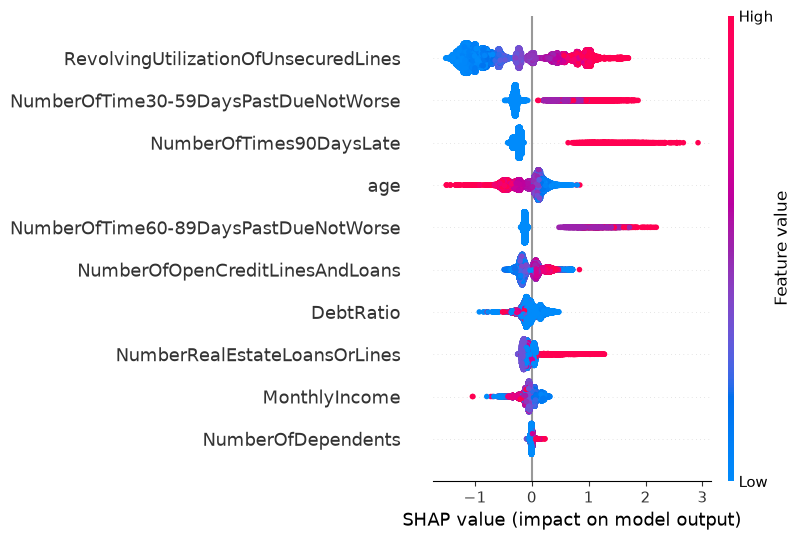

In [10]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

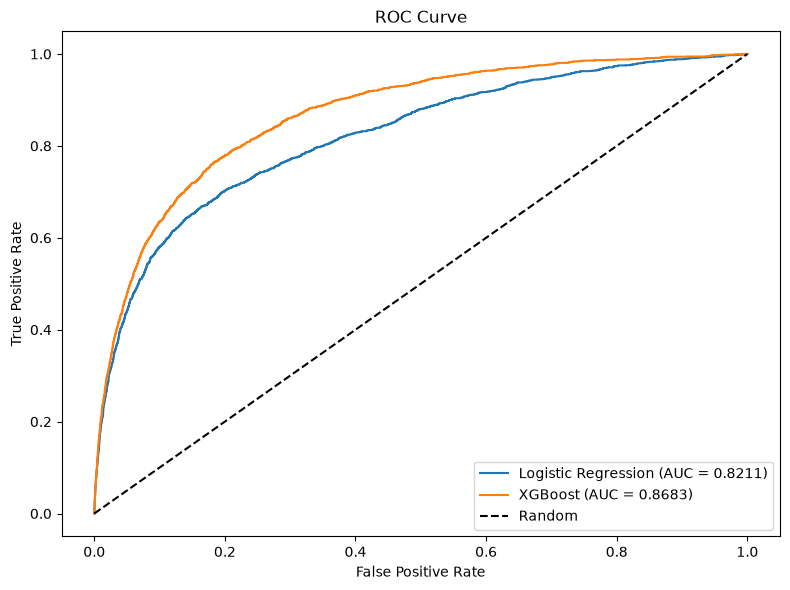

In [11]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for model, name in [(lr, 'Logistic Regression'), (xgb_model, 'XGBoost')]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

**Note:** `cs-test.csv` is Kaggle's unlabeled competition test set (`SeriousDlqin2yrs` is empty — it's only used for scoring Kaggle submissions via `sampleEntry.csv`). It is not a valid local evaluation set. Model evaluation uses the held-out `X_test`/`y_test` split above instead.